<table border=0 width="100%"><tr><td><p align="left"><img src="..\img\logo.png" align="left" width=300></p></td><td><font size=3><B>金融统计基础（郑海超）</B></font></td></tr></table>

# 内容
- 上周课后学习分享
- 统计与假设检验
- 金融时间序列统计
    -- 收益率
    -- 波动率
    -- 夏普比率
- 本周课后作业

# 上周课后学习交流

- 完成实验 - 应用streamlit和大模型做一个预测股价波动方向的应用
- 文献阅读 - Are Monthly Seasonals Real? A Three Century Perspective （本节课后续时间段分享）

## 实验分享 - 应用streamlit和大模型做一个预测股价波动方向的APP

# 假设检验举例

你朋友有一枚硬币，他总猜对正面。你怀疑硬币动了手脚（两面都是正面）。

你给出的假设是：
- 原假设（H₀）：硬币是公平的。（先假设他无辜）
- 备择假设（H₁）：硬币不公平，动了手脚。
- 实验：你让他抛10次，全是正面。
- 根据实验结果接受还是拒绝原假设

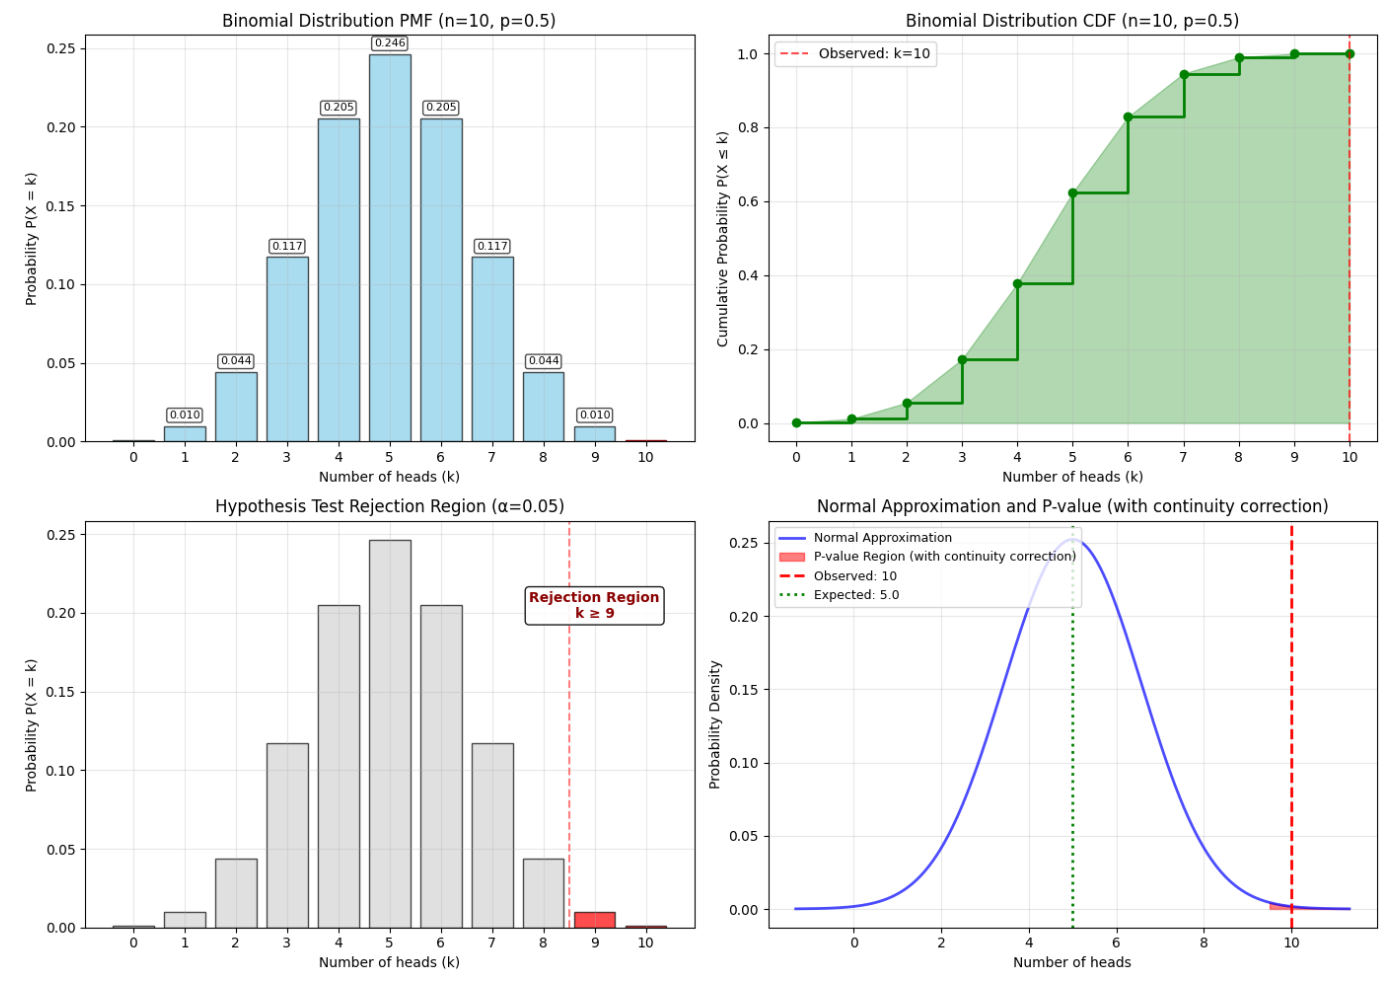

**二项分布**（Binomial Distribution）描述了在 $n$ 次独立的伯努利试验中成功次数的概率分布。每次试验只有两种可能的结果：**成功**（概率为 $p$）或**失败**（概率为 $1-p$）。

**概率质量函数**

二项分布的概率质量函数给出了恰好获得 $k$ 次成功的概率：

$$
P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}
$$

**公式分解：**
- $\displaystyle \binom{n}{k} = \frac{n!}{k!(n-k)!}$：**组合数**，表示从 $n$ 次试验中选择 $k$ 次成功的方式数
- $p^k$：$k$ 次成功的概率
- $(1-p)^{n-k}$：$n-k$ 次失败的概率

**参数说明：**
- $n$：试验次数，正整数
- $k$：成功次数，$k = 0, 1, 2, \dots, n$
- $p$：每次试验的成功概率，$0 \leq p \leq 1$


https://ai4science.feishu.cn/wiki/WEOrwCOZxiWRBlkU5EZcdJijnuh

# 统计与假设检验

In [ ]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# seaborn 会自动设置一些样式
sns.set_style("whitegrid")
sns.set(font=['SimHei', 'DejaVu Sans'])  # 设置字体
plt.rcParams['axes.unicode_minus'] = False

## 数据分布：以整体分布为例

正态分布的重要特点
- 对称性：关于均值$\mu$对称
- 单峰性：只有一个峰值，位于$x=\mu$处
- 渐近性：曲线向两侧无限延伸，逐渐接近横轴但永不相交


正态分布的应用场景
- 自然现象：身高、体重、测量误差等
- 金融领域：股票收益率、资产价格变化等（这里是近似）
- 质量控制：产品质量指标、生产过程控制等
- 统计推断：假设检验的理论基础

In [ ]:
# 生成正态分布数据
mu, sigma = 0, 1  # 标准正态分布
normal_data = np.random.normal(mu, sigma, 10000)
print(f"\n正态分布数据特征：均值 = {normal_data.mean():.4f}, 标准差 = {normal_data.std():.4f}")

In [ ]:
# 绘制直方图（归一化为概率密度） - density=True (显示概率密度)
# 创建画布
plt.figure(figsize=(12, 10))

# 子图1：正态分布
plt.subplot(2, 2, 1)
plt.hist(normal_data, bins=50, density=True, alpha=0.7, color='blue')
x = np.linspace(-4, 4, 1000)
plt.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', lw=2, label='理论分布')
plt.xlabel('值')
plt.ylabel('概率密度')
plt.title('正态分布')
plt.legend()
plt.grid(True, alpha=0.3)

## 总体与抽样

抽样是从总体中选取部分样本进行研究的过程，目的是通过样本推断总体特征。

抽样的重要性
- 节省成本和时间：研究全部总体往往代价高昂
- 可行性：有些总体过大或无限，无法进行全面调查
- 准确性：合理设计的抽样可以提供准确的总体估计
- 破坏性测试：某些测试会破坏样本，只能抽样

In [ ]:
# 生成总体数据（正态分布）
population_mu, population_sigma = 50, 10
population = np.random.normal(population_mu, population_sigma, 100000)

In [ ]:
population.shape

In [ ]:
# 简单随机抽样
sample_size = 100
sample = np.random.choice(population, sample_size)

In [ ]:
print(f"\n抽样结果：")
print(f"总体均值: {population.mean():.2f}, 总体标准差: {population.std():.2f}")
print(f"样本均值: {sample.mean():.2f}, 样本标准差: {sample.std():.2f}")
print(f"抽样误差（均值）: {abs(sample.mean() - population.mean()):.2f}")

In [ ]:
# 抽样分布可视化
print("\n抽样分布可视化")

# 创建画布
plt.figure(figsize=(12, 5))

# 子图1：总体分布
plt.subplot(1, 2, 1)
plt.hist(population, bins=50, density=True, alpha=0.7, color='blue')
plt.xlabel('值')
plt.ylabel('概率密度')
plt.title(f'总体分布 (n={len(population)})')
plt.grid(True, alpha=0.3)

# 子图2：样本分布
plt.subplot(1, 2, 2)
plt.hist(sample, bins=20, density=True, alpha=0.7, color='red')
plt.xlabel('值')
plt.ylabel('概率密度')
plt.title(f'样本分布 (n={sample_size})')
plt.grid(True, alpha=0.3)

## 大数定理

大数定理（Law of Large Numbers）：随着样本量的增加，样本均值趋近于总体均值。

In [ ]:
# 生成不同样本量的均值
sample_sizes = [10, 50, 100, 500, 1000, 5000, 10000, 50000]
sample_means = []

for size in sample_sizes:
    sample = np.random.choice(population, size)
    sample_means.append(sample.mean())

print("\n样本量与样本均值的关系：")
for size, mean in zip(sample_sizes, sample_means):
    print(f"样本量: {size}, 样本均值: {mean:.4f}, 与总体均值的差异: {abs(mean - population_mu):.4f}")


In [ ]:
# 大数定理可视化
print("\n大数定理可视化")

# 创建画布
plt.figure(figsize=(10, 6))

# 绘制样本均值随样本量变化的曲线
plt.plot(sample_sizes, sample_means, 'o-', color='blue', label='样本均值')

# 绘制总体均值参考线
plt.axhline(y=population_mu, color='red', linestyle='--', linewidth=2, label=f'总体均值 ({population_mu:.2f})')

# 设置对数坐标轴
plt.xscale('log')

# 添加标签和标题
plt.xlabel('样本量 (对数刻度)')
plt.ylabel('样本均值')
plt.title('大数定理演示：样本均值随样本量增加趋近于总体均值')
plt.legend()
plt.grid(True, alpha=0.3)

## 中心极限定理

中心极限定理
中心极限定理（Central Limit Theorem, CLT）：无论总体分布如何，样本均值的分布近似正态分布。

中心极限定理的详细条件
1. 样本相互独立：各个样本之间不相关
2. 样本量足够大：通常$n\geq30$，对于接近正态的总体可更小
3. 总体方差有限：$\sigma^2 < \infty$
4. 同分布：所有样本来自同一总体分布

In [ ]:
# 从非正态总体（指数分布）中抽样
population_exponential = np.random.exponential(1, 100000)

In [ ]:
# 创建画布
plt.figure(figsize=(12, 10))

# 子图1：原始总体分布（指数分布）
plt.subplot(2, 2, 1)
plt.hist(population_exponential, bins=50, density=True, alpha=0.7, color='blue')
x = np.linspace(0, 5, 1000)
plt.plot(x, stats.expon.pdf(x, 0, 1), 'r-', lw=2, label='理论分布')
plt.xlabel('值')
plt.ylabel('概率密度')
plt.title(f'原始总体分布（指数分布）\n均值: {population_exponential.mean():.2f}, 标准差: {population_exponential.std():.2f}')
plt.legend()
plt.grid(True, alpha=0.3)

In [ ]:
# 进行多次抽样，计算每次抽样的均值
sample_size = 30
num_samples = 1000
sample_means_clt = []

for _ in range(num_samples):
    sample = np.random.choice(population_exponential, sample_size)
    sample_means_clt.append(sample.mean())

# 计算样本均值分布的统计量
clt_mean = np.mean(sample_means_clt)
clt_std = np.std(sample_means_clt)
print(f"\n样本均值分布特征：")
print(f"均值: {clt_mean:.4f}, 标准差: {clt_std:.4f}")
print(f"总体均值: {population_exponential.mean():.4f}")
print(f"理论标准差（标准误）: {population_exponential.std()/np.sqrt(sample_size):.4f}")
print(f"\n中心极限定理验证：")
print(f"  - 样本均值分布的均值接近总体均值")
print(f"  - 样本均值分布的标准差接近理论标准误")
print(f"  - 无论原总体分布如何，样本均值分布近似正态分布")

In [ ]:
# 子图2：样本均值分布（n=30）
plt.subplot(2, 2, 2)
plt.hist(sample_means_clt, bins=30, density=True, alpha=0.7, color='green')

# 绘制理论正态分布曲线
x = np.linspace(clt_mean - 4*clt_std, clt_mean + 4*clt_std, 1000)
plt.plot(x, stats.norm.pdf(x, clt_mean, clt_std), 'r-', lw=2)

plt.xlabel('样本均值')
plt.ylabel('概率密度')
plt.title(f'样本均值分布（n={sample_size}）\n均值: {clt_mean:.2f}, 标准差: {clt_std:.2f}')
plt.grid(True, alpha=0.3)

In [ ]:
plt.subplot(2, 2, 3)

# 尝试不同样本量
different_sample_sizes = [5, 15, 30, 50]
colors = ['blue', 'green', 'red', 'purple']

for i, n in enumerate(different_sample_sizes):
    # 生成样本均值
    temp_sample_means = []
    for _ in range(1000):
        temp_sample = np.random.choice(population_exponential, n)
        temp_sample_means.append(temp_sample.mean())
    
    # 绘制直方图
    plt.hist(temp_sample_means, bins=20, alpha=0.5, density=True, color=colors[i], label=f'n={n}')

plt.xlabel('样本均值')
plt.ylabel('概率密度')
plt.title('不同样本量的样本均值分布对比')
plt.legend()
plt.grid(True, alpha=0.3)

## 假设检验的基本原理

假设检验（Hypothesis Testing）是一种统计推断方法，用于判断样本数据是否支持某个关于总体的假设。

假设检验的核心思想
- 小概率事件原理：小概率事件在一次试验中几乎不可能发生
- 反证法：先假设原假设成立，然后看样本数据是否支持该假设
- 概率性决策：基于样本数据计算的概率做出决策，而非绝对肯定或否定


假设检验的步骤
1. 建立原假设（$H_0$）和备择假设（$H_1$）
   - 原假设：通常是研究者想要拒绝的假设，代表现状或无差异
   - 备择假设：通常是研究者想要支持的假设，代表变化或有差异
2. 选择显著性水平$\alpha$（通常为0.05）
   - 定义：原假设为真时拒绝原假设的最大允许概率
   - 常见值：0.05, 0.01, 0.10
3. 计算检验统计量
   - 根据假设类型和数据特征选择合适的检验统计量
   - 如t统计量、z统计量、$\chi^2$统计量等
4. 确定临界值或计算p值
   - 临界值法：根据显著性水平和自由度确定拒绝域边界
   - p值法：计算观察到的统计量或更极端情况的概率
5. 做出决策：拒绝或不拒绝原假设
   - 临界值法：如果检验统计量落在拒绝域，则拒绝$H_0$
   - p值法：如果p值 < $\alpha$，则拒绝$H_0$
   - 注意：统计上不使用"接受$H_0$"，而是"不拒绝$H_0$"，因为我们没有证明$H_0$为真

假设检验补充说明
显著性水平$\alpha$的选择依据
- 研究领域惯例：不同领域有不同的标准
- 错误后果：
  * 若第一类错误后果严重，选择较小的$\alpha$（如0.01）
  * 若第二类错误后果严重，选择较大的$\alpha$（如0.10）
- 样本量：样本量较大时，可选择较小的$\alpha$
- 研究阶段：探索性研究可选择较大的$\alpha$，验证性研究选择较小的$\alpha$

p值的详细解释
- 定义：在原假设$H_0$成立的条件下，观察到当前检验统计量或更极端情况的概率
- 含义：
  * p值越小，原假设成立的可能性越小
  * p值不是原假设为真的概率，而是数据与原假设不一致的程度
  * p值不衡量效应大小，只衡量证据强度
- 正确解读：
  * p < $\alpha$：拒绝$H_0$，样本数据提供了足够的证据支持$H_1$
  * p ≥ $\alpha$：不拒绝$H_0$，样本数据没有提供足够的证据支持$H_1$

两类错误
- 第一类错误（$\alpha$错误）：原假设为真时，拒绝原假设
  * 概率为$\alpha$，由研究者预先设定
  * 又称"假阳性错误"或"弃真错误"
  * 例如：将无病的人诊断为有病

- 第二类错误（$\beta$错误）：原假设为假时，不拒绝原假设
  * 概率为$\beta$，与样本量、效应大小、$\alpha$等有关
  * 又称"假阴性错误"或"取伪错误"
  * 例如：将有病的人诊断为无病

## 独立样本t检验的基本原理

独立样本t检验（Independent Samples t-test）用于比较两个独立样本的均值是否存在显著差异。

独立样本t检验的假设
- 原假设$H_0$：$\mu_1 = \mu_2$（两个总体均值相等）
- 备择假设$H_1$：
  - 双侧检验：$\mu_1 \neq \mu_2$（两个总体均值不相等）

独立样本t检验的假设条件
1. 独立性：两个样本相互独立，没有配对或关联关系
2. 正态性：每个样本来自正态分布总体
   - 当样本量较大时（$n\geq30$），中心极限定理保证近似正态
   - 可通过Shapiro-Wilk检验或可视化方法（直方图、Q-Q图）检验
3. 方差齐性：两个总体的方差相等（$\sigma_1^2 = \sigma_2^2$）
   - 可通过Levene检验或Bartlett检验进行统计检验
   - 当方差不齐时，可使用Welch's t检验

检验统计量计算公式
$$
t = \frac{\bar{X}_1 - \bar{X}_2}{s_p \cdot \sqrt{\frac{1}{n_1} + \frac{1}{n_2}}}
$$

其中：
- $\bar{X}_1, \bar{X}_2$：两个样本的均值
- $n_1, n_2$：两个样本的样本量
- $s_p$：合并标准差，计算公式为：
  $$
  s_p = \sqrt{\frac{(n_1-1)s_1^2 + (n_2-1)s_2^2}{n_1 + n_2 - 2}}
  $$
- $s_1, s_2$：两个样本的标准差
- 自由度$df = n_1 + n_2 - 2$

In [ ]:
# 生成两组独立样本数据
group1 = np.random.normal(50, 10, 100)  # 第一组：均值50，标准差10
group2 = np.random.normal(55, 10, 100)  # 第二组：均值55，标准差10

print(f"第一组样本：均值 = {group1.mean():.2f}, 标准差 = {group1.std():.2f}, 样本量 = {len(group1)}")
print(f"第二组样本：均值 = {group2.mean():.2f}, 标准差 = {group2.std():.2f}, 样本量 = {len(group2)}")

In [ ]:
# 创建画布
plt.figure(figsize=(12, 5))

# 子图1：直方图
plt.subplot(1, 2, 1)
plt.hist(group1, bins=20, alpha=0.7, label='组1', color='blue', density=True)
plt.hist(group2, bins=20, alpha=0.7, label='组2', color='red', density=True)
plt.xlabel('值')
plt.ylabel('概率密度')
plt.title('两个样本的分布直方图')
plt.legend()
plt.grid(True, alpha=0.3)

In [ ]:
# 4.2.1 方差齐性检验
print("\n方差齐性检验（Levene检验）")
levene_stat, levene_p = stats.levene(group1, group2)
print(f"Levene检验统计量: {levene_stat:.4f}, p值: {levene_p:.4f}")
if levene_p > 0.05:
    print("p值 > 0.05，不拒绝方差齐性假设，认为两组方差相等。")
    equal_var = True
else:
    print("p值 ≤ 0.05，拒绝方差齐性假设，认为两组方差不相等。")
    equal_var = False

In [ ]:
print("\n执行t检验")
if equal_var:
    print("使用标准独立样本t检验（方差齐性）")
    t_stat, p_value = stats.ttest_ind(group1, group2, equal_var=True)
    df = len(group1) + len(group2) - 2
else:
    print("使用Welch's t检验（方差不齐）")
    t_stat, p_value = stats.ttest_ind(group1, group2, equal_var=False)
    # 计算Welch-Satterthwaite自由度
    s1_sq = group1.var()
    s2_sq = group2.var()
    n1 = len(group1)
    n2 = len(group2)
    df = (s1_sq/n1 + s2_sq/n2)**2 / ((s1_sq/n1)**2/(n1-1) + (s2_sq/n2)**2/(n2-1))

print(f"t统计量: {t_stat:.4f}")
print(f"自由度: {df:.2f}")
print(f"p值: {p_value:.4f}")

In [ ]:
# 可视化t分布和t统计量
plt.figure(figsize=(12, 8))

# 生成t分布的x值范围
x = np.linspace(-4, 4, 1000)
y = stats.t.pdf(x, df)

# 绘制t分布曲线
plt.plot(x, y, 'b-', linewidth=2, label=f't分布 (df={df:.1f})')

# 标记临界区域 (双侧检验，α=0.05)
critical_value = stats.t.ppf(1 - alpha/2, df)
x_fill_left = np.linspace(-4, -critical_value, 100)
x_fill_right = np.linspace(critical_value, 4, 100)

plt.fill_between(x_fill_left, stats.t.pdf(x_fill_left, df), 
                 alpha=0.3, color='red', label=f'拒绝域 (α={alpha})')
plt.fill_between(x_fill_right, stats.t.pdf(x_fill_right, df), 
                 alpha=0.3, color='red')

# 标记计算得到的t统计量位置
plt.axvline(t_stat, color='green', linestyle='--', linewidth=2, 
            label=f'样本t统计量 = {t_stat:.4f}')
plt.axvline(-t_stat, color='green', linestyle='--', linewidth=2)

# 标记临界值
plt.axvline(critical_value, color='red', linestyle=':', linewidth=1.5, 
            label=f'临界值 = ±{critical_value:.4f}')
plt.axvline(-critical_value, color='red', linestyle=':', linewidth=1.5)

# 添加说明文本
plt.text(0, max(y)*0.8, f'p值 = {p_value:.4f}\n'
                        f'自由度 = {df:.1f}\n'
                        f'显著性水平 α = {alpha}', 
         ha='center', va='center', 
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

# 设置图形属性
plt.title('独立样本t检验：t统计量在原假设下的分布', fontsize=14, fontweight='bold')
plt.xlabel('t值', fontsize=12)
plt.ylabel('概率密度', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, max(y)*1.1)

# 添加决策结果注释
decision_text = "拒绝原假设" if p_value < alpha else "不拒绝原假设"
plt.figtext(0.5, 0.01, f'决策结果: {decision_text} (p值 {p_value:.4f} {"<" if p_value < alpha else "≥"} α={alpha})', 
            ha='center', fontsize=12, bbox=dict(boxstyle="round,pad=0.5", facecolor="lightyellow", alpha=0.8))

plt.tight_layout()
plt.subplots_adjust(bottom=0.1)
plt.show()


可视化解释:

1. 蓝色曲线表示在原假设成立时（两组均值相等）t统计量的理论分布
2. 红色阴影区域表示拒绝域（双侧检验，α=0.05）
3. 绿色虚线表示本次检验计算得到的t统计量位置
4. 如果t统计量落在红色拒绝域内，则拒绝原假设
5. p值表示观察到的差异（或更极端差异）在原假设成立时的概率

由于 |t统计量| = 3.9600 > 临界值 = 1.9720
t统计量落在拒绝域内，因此拒绝原假设

In [ ]:
# 做出决策（用p值）
print("\n做出决策")
alpha = 0.05
if p_value < alpha:
    print(f"p值 ({p_value:.4f}) < α ({alpha})，拒绝原假设，认为两组均值存在显著差异。")
else:
    print(f"p值 ({p_value:.4f}) ≥ α ({alpha})，不拒绝原假设，认为两组均值无显著差异。")


t检验的注意事项
1. t检验对正态性假设的稳健性：当样本量较大时，t检验对偏离正态性的情况较为稳健
2. 方差齐性的影响：当方差不齐时，Welch's t检验是更好的选择
3. 样本量不平衡的影响：当两组样本量差异较大时，方差齐性假设更为重要
4. 多重比较问题：多次进行t检验会增加第一类错误的概率，需进行校正

# 认识时间序列与金融时间序列

## 时间戳

针对时间戳数据，Pandas 提供了 Timestamp 类型。与前面介绍的一样，它本质上是 Python 的原生 datetime 类型的替代品，但是在性能更好的 numpy.datetime64 类型的基础上创建。对应的索引数据结构是 DatetimeIndex。

In [ ]:
import pandas as pd
date = pd.to_datetime("4th of December, 2025")

delta = pd.Timedelta("1 day")
date + delta

A Timedelta represents a duration of time in the form of days, hours, minutes, seconds, milliseconds, microseconds, nanoseconds. It is useful for indexing, slicing and manipulating time series data.

In [ ]:
td1 = pd.Timedelta('1 day')
td2 = pd.Timedelta('3 hours')
td1 + td2

In [ ]:
td1 - td2  # 1 day - 3 hours

In [ ]:
pd.Timedelta('1day 3hours')
td1 + td2  # 1 day + 3 hours

In [ ]:
date+td1

In [ ]:
import pandas as pd
from datetime import datetime

# Create a DataFrame with some dates
df = pd.DataFrame({'start_date': ['2025-01-01', '2025-01-02', '2025-01-03']})

# Convert the 'start_date' column to a datetime data type
df['start_date'] = pd.to_datetime(df['start_date'])

# Create a Timedelta of 1 day
seven_day = pd.Timedelta(days=7)

# Add the Timedelta to the 'start_date' column to get the 'end_date' column

df['end_date'] = df['start_date'] + seven_day

# Print the DataFrame
print(df)

## 创建时间序列数据

### 手动创建时间序列数据

In [ ]:
import pandas as pd
import numpy as np
index = pd.date_range("2025-01-01", "2025-01-10")
data = np.random.randn(len(index))
series = pd.Series(data,index=index)
series

## 从文件中读取时间序列数据

### 直接读取并转为为日期索引

In [ ]:
import pandas as pd

直接读取并识别转换为日期类型，而且设置为index
- file_path
- index_col
- parse_dates

In [ ]:
file_path = "index_sh.csv"
df_sh = pd.read_csv(file_path)

In [ ]:
# 查看数据类型
df_sh.info()

In [ ]:
df_sh.head()

## 课堂操作：大家尝试读取寒武纪的市场时间序列数据

In [ ]:
han_file_path = "688256.csv"

In [ ]:
han_df = 

In [ ]:
han_df.index

## 时间序列切片

In [ ]:
# 直接使用时间字符串切片,首先对索引进行排序
han_df = pd.read_csv(han_file_path,index_col="trade_date",parse_dates=True)

han_df = han_df.sort_index()

# 现在尝试切片
han_df["2025-09-01":"2025-09-08"]

**一个问题**：为什么没有2025-09-07这一天的数据？

In [ ]:
# 使用 loc 对close列进行切片
start_date = '2025-08-15'
end_date = '2025-09-08'
han_df["close"].

使用between_time('09:00', '15:00')这样的区间切片

In [ ]:
# 创建带时间的日期时间索引
datetime_rng = pd.date_range('2025-09-15', periods=72, freq='h')
df_time = pd.DataFrame({'value': range(72)}, index=datetime_rng)

# 选择特定时间段
df_time.

使用at_time函数选择特定时间点的数据

In [ ]:
# 使用at_time函数选择特定时间点的数据
df_time.at_time('12:00')  # 每天12点的数据

# 收益率、利率与金钱的时间价值

## 收益率与利率

算术百分比收益率（简单收益率）
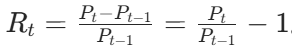

- close.pct_change()
- han_df.close.shift(1)

In [ ]:
han_df.head()

In [ ]:
# pct_change()





In [ ]:
# han_df.close.shift(1)
pct_chg = 




**上述收益率和存款利率有什么区别？**

存款利率是收益率的一种，但收益率的概念远比存款利率广泛。

存款利率，特别是中央银行设定的政策利率（如基准利率），是整个金融市场的定价基石和无风险收益的标杆。

- 无风险收益率 (Risk-Free Rate)：通常将期限相同的国债利率或顶级银行的存款利率视为无风险收益率。任何其他投资都需要提供高于这个水平的预期收益率，否则理性投资者不会去承担额外风险。

- 风险溢价 (Risk Premium)：投资者承担风险所要求的额外补偿。

> 一项投资的期望收益率 ≈ 无风险收益率 (如存款利率) + 风险溢价

> 例如：10年期国债利率为1.5%，而某公司发行的债券收益率为5%。那么这额外的3.5%就是投资者为承担该公司可能违约的风险而要求的风险溢价。

**实际收益率**

- 名义收益率 (Nominal Yield)：票面或账面上显示的收益率（如存款利率1.5%）。

- 实际收益率 (Real Yield) = 名义收益率 - 通货膨胀率 (Inflation Rate)

> 如果存款利率为1.5%，而通货膨胀率为3%，那么你的实际收益率是 -1.5%，意味着你的购买力在下降。

> 投资者在评估任何投资的真实价值时，都必须考虑通货膨胀因素，并与存款的实际收益率进行比较。

**央行存款基准利率**

央行存款基准利率是中央银行公布的指导性利率，是商业银行存款利率的定价基础。各商业银行会以此为基础，并结合自身情况、市场资金供求等因素来确定实际的存款利率。因此，它直接影响银行吸收存款的成本和储户的利息收入。

## 现值公式

现值（Present Value, PV）是将未来现金流按特定折现率折算到当前时点的价值，其计算公式为：

$$
PV = \frac{FV}{(1 + r)^n}
$$

**其中：**
- \(PV\)：现值（Present Value）
- \(FV\)：终值（Future Value）
- \(r\)：每期折现率（Discount Rate per Period）
- \(n\)：期数（Number of Periods）

## 终值（期末价值）公式

终值（Future Value, FV）是当前现金流按特定收益率在未来某个时点的价值，其计算公式为：

$$
FV = PV \times (1 + r)^n
$$

**其中：**
- \(FV\)：终值（Future Value）
- \(PV\)：现值（Present Value）
- \(r\)：每期收益率（Interest Rate per Period）
- \(n\)：期数（Number of Periods）

In [ ]:
# 评价每天收益率
r = 0.0007
pv = 100

In [ ]:
index = pd.date_range("2025-01-01","2025-09-10",freq="d")
index

In [ ]:
ts = pd.DataFrame(index=index)

In [ ]:
ts["return"] = r

- .cumprod()
- .shift(1)

In [ ]:
# compute the future value based on returns
fv = pv*(1+ts["return"])




In [ ]:
ts["fv"] = fv

In [ ]:
ts["fv"].fillna(100,inplace=True)
ts

## 年化收益率

如果每天的收益率不变，那么年化收益率：
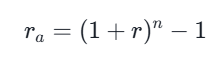

如果每天的收益率不同，投资k天，那么年化收益率如下：
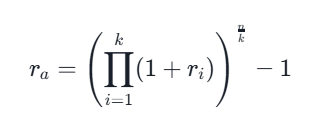

推导过程参考：
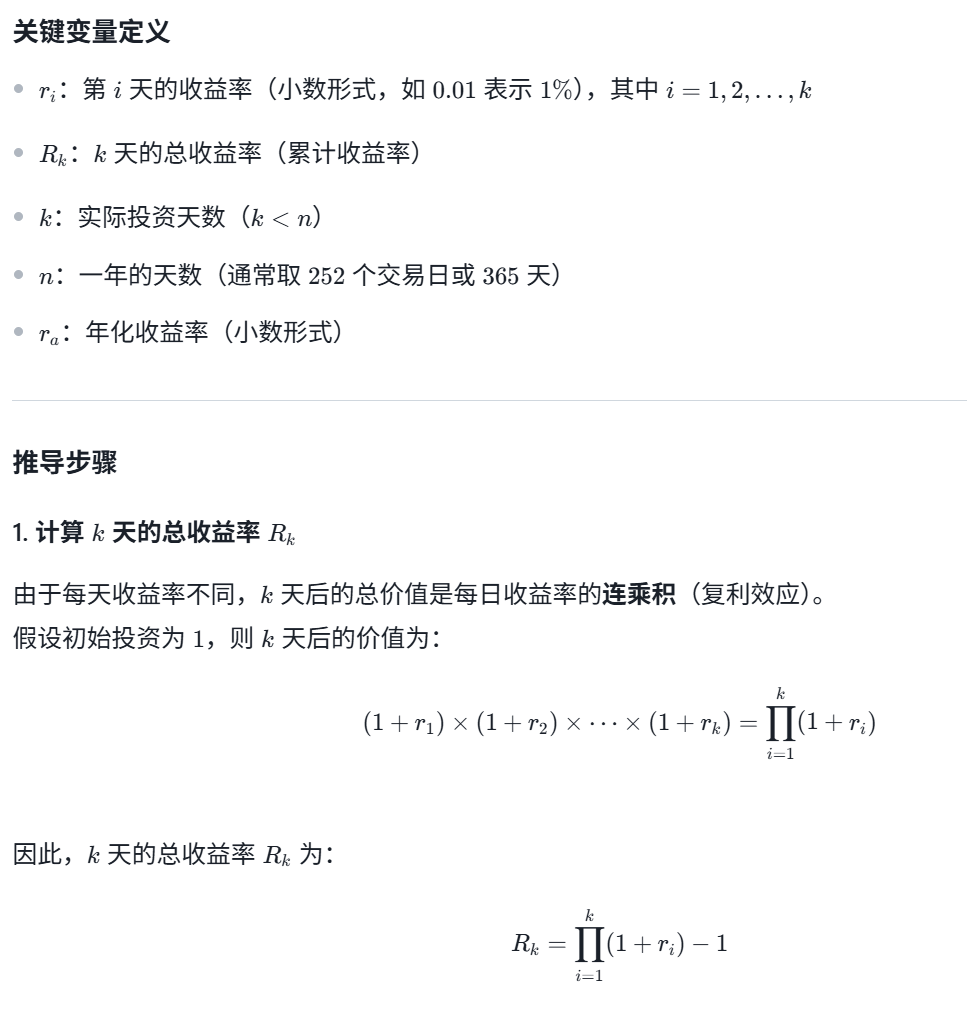



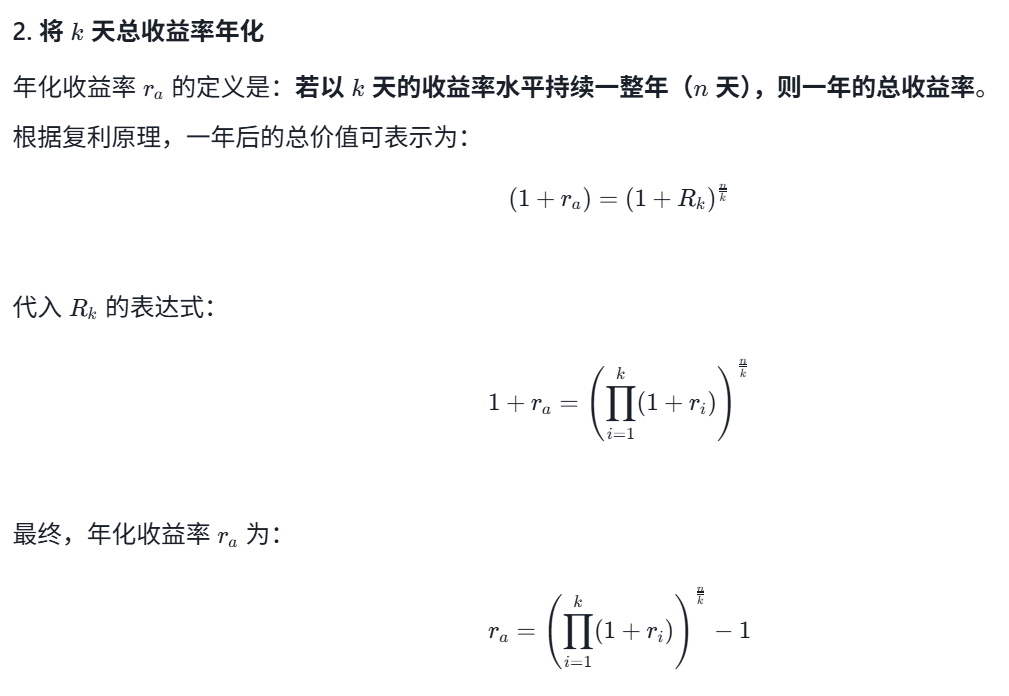

# 对数收益率

## 对数收益率计算及其优势

[对数收益率](https://www.doubao.com/thread/we5262c35360ed274)

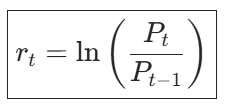

- np.log(close/close.shift(1))
- close.apply(np.log).diff()

In [ ]:
# 如何计算宁德时代的对数收益率
import pandas as pd
import numpy as np
han_file_path = "688256.csv"
han_df = pd.read_csv(han_file_path,index_col="trade_date",parse_dates=True)
# 对han_df进行排序
han_df = han_df.sort_index()
close = han_df["close"]
close.head()
import numpy as np
logRtn = 
logRtn.head()

In [ ]:
# use shift to get the log return
han_df["log_r"] = logRtn
han_df["log_r"]

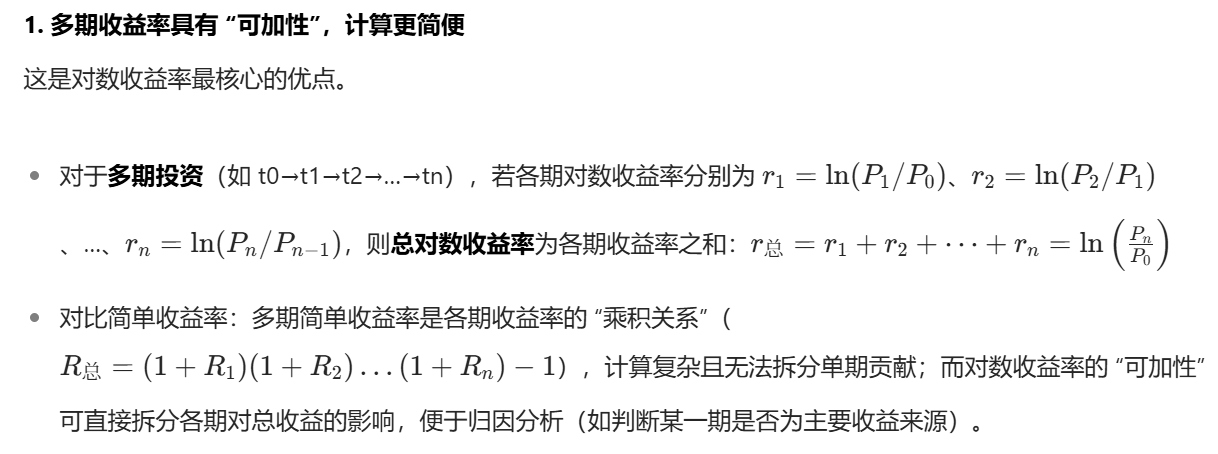

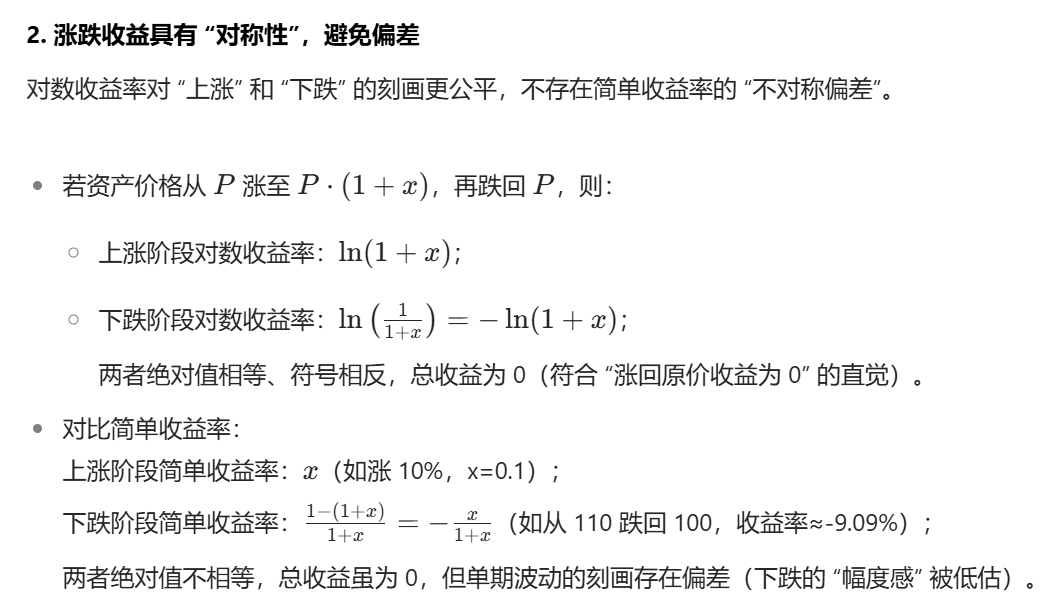

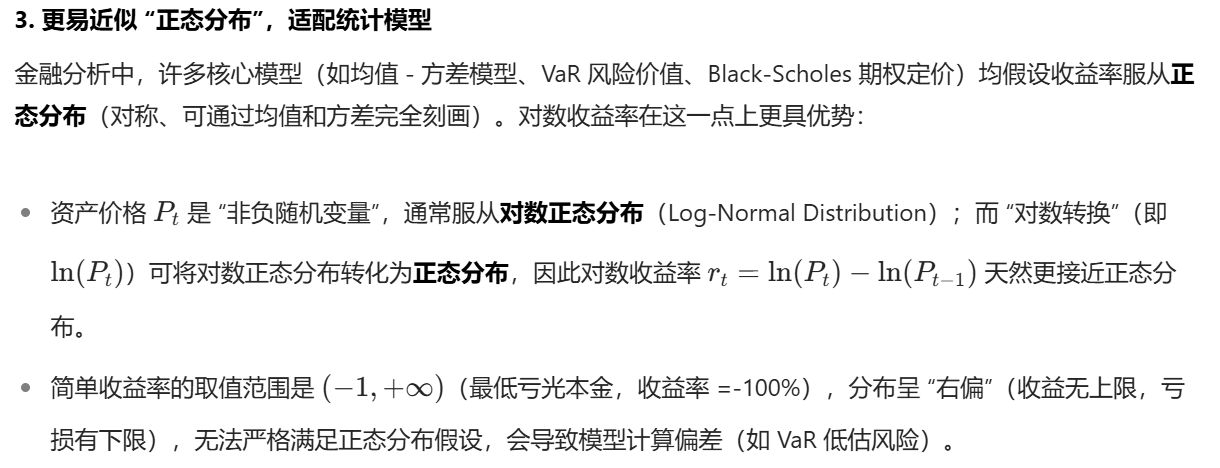

<b> 即期末累计金额 = 起初金额 * exp(各期对数收益率之和）</b>
对数收益率可以直接相加，然后转成以e为底的指数， 再乘以原资产价格， 就是K个周期后的资产的价格

推导过程

设 $A_0$ 为初始金额，$A_i$ 为第 $i$ 期期末的累计金额，$r_i$ 为第 $i$ 期的对数收益率。根据对数收益率的定义：

$$
r_i = \ln\left(\frac{A_i}{A_{i-1}}\right) \quad \text{其中 } i = 1, 2, \dots, n
$$

---

### 第一步：对等式求和

对上述等式从 $i = 1$ 到 $n$ 求和：

$$
\sum_{i=1}^{n} r_i = \sum_{i=1}^{n} \ln\left(\frac{A_i}{A_{i-1}}\right)
$$

---

### 第二步：应用对数性质

利用对数运算性质 $\ln(a) + \ln(b) = \ln(ab)$，将求和转化为乘积的对数：

$$
\sum_{i=1}^{n} r_i = \ln\left( \prod_{i=1}^{n} \frac{A_i}{A_{i-1}} \right)
$$

---

### 第三步：连乘积化简

注意到乘积项中相邻分子分母相消（叠乘消元）：

$$
\prod_{i=1}^{n} \frac{A_i}{A_{i-1}} = 
\frac{A_1}{A_0} \times \frac{A_2}{A_1} \times \cdots \times \frac{A_n}{A_{n-1}} = \frac{A_n}{A_0}
$$

代入上式得：

$$
\sum_{i=1}^{n} r_i = \ln\left( \frac{A_n}{A_0} \right)
$$

---

### 第四步：指数化处理

对等式两边同时取指数函数（以自然常数 $e$ 为底）：

$$
\exp\left( \sum_{i=1}^{n} r_i \right) = \frac{A_n}{A_0}
$$

---

### 第五步：整理得到最终公式

移项即得到最终公式：

$$
\boxed{ A_n = A_0 \times \exp\left( \sum_{i=1}^{n} r_i \right) }
$$

## buy and hold

- logRtn.cumsum().apply(np.exp)

In [ ]:
# compute the cum_logRtn
cum_logRtn = 
cum_logRtn.plot()

In [ ]:
import matplotlib.pyplot as plt

# get the capital you have
capital = 10000
ax = (han_df[["log_r"]].cumsum().apply(np.exp)*capital).plot()
ax.legend(["Capital"])  # 将标签作为列表传递
plt.show()

## 对数收益率转换为年化收益率

#### 1. 单周期平均对数收益

观测到 $n$ 个短周期的对数收益率 $r_1, r_2, \ldots, r_n$，其样本均值为：

$$\bar{r} = \frac{1}{n} \sum_{t=1}^{n} r_t$$

#### 2. 年度总对数收益

一年包含 $T$ 个短周期，总对数收益为 $T$ 个单周期平均收益之和：

$$\text{年度总对数收益} = \bar{r} \times T$$

#### 3. 最终年化对数收益率公式

（因对数收益本身已反映连续复利，年化直接为均值乘周期数）

$$\text{年化对数收益} = \bar{r} \times T$$

| 特性 | 算术收益率 (Simple Return) | 对数收益率 (Log Return) |
| :--- | :--- | :--- |
| **单期定义** | $r_t = \frac{P_t - P_{t-1}}{P_{t-1}}$ | $r_{log-t} = \ln(\frac{P_t}{P_{t-1}})$ |
| **多期计算** | 几何相乘：$(1 + r_1)(1 + r_2)...(1 + r_n) - 1$ | **代数相加**：$r_{log1} + r_{log2} + ... + r_{logn}$ |
| **年化方法** | 需复利折算：$(1 + \bar{r}_{period})^{T} - 1$ | **直接相乘**：$\bar{r}_{log-period} \times T$ |

## 课堂练习：比较贵州茅台喝寒武纪的对数收益率
- 计算贵州茅台2020-07-19 至今（最新数据）的对数收益率
- 并比较贵州茅台和寒武纪的对数收益率的差异
- 如果采用buy and hold策略，你愿意购买哪个股票

In [ ]:
# 比较贵州茅台和寒武纪的对数收益率






# 波动率与夏普比率计算

## 波动率计算

### 观察收益率的分布

In [ ]:
# 可视化hand_df的log_r
han_df["log_r"].plot()

In [ ]:
# 可视化hand_df的log_r的直方图
han_df["log_r"].hist()


#### 更加细致地展示han_df的log_r的直方图
- 设置bins的数量

In [ ]:
han_df["log_r"].hist(bins = 100)

#### 拟合收益率的分布曲线

pip install scipy

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import matplotlib as mpl 

# 设置中文字体 
mpl.rcParams['font.sans-serif'] = ['SimHei'] 
mpl.rcParams['axes.unicode_minus'] = False 

# 假设han_df是包含对数收益率的数据框
data = han_df["log_r"].dropna()

# 绘制直方图
data.hist(bins=100, density=True, alpha=0.7, color='blue')

# 计算样本均值和标准差
mu, std = norm.fit(data)

# 生成理论正态分布的PDF曲线
x = np.linspace(data.min(), data.max(), 100)
y = norm.pdf(x, mu, std)

# 叠加PDF曲线
plt.plot(x, y, 'r-', linewidth=2)
plt.title(f'直方图与正态分布拟合 (μ={mu:.4f}, σ={std:.4f})')
plt.xlabel('对数收益率')
plt.ylabel('密度')
plt.show()

#### P-P图（概率-概率图）
比较样本累积分布函数与理论累积分布函数，若数据符合理论分布，点应大致呈直线。

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import matplotlib as mpl 

# 设置中文字体 
mpl.rcParams['font.sans-serif'] = ['SimHei'] 
mpl.rcParams['axes.unicode_minus'] = False 

# 计算经验CDF和理论CDF
n = len(data)
empirical_cdf = np.arange(1, n+1)/n
theoretical_cdf = norm.cdf(np.sort(data), mu, std)

# 绘制P-P图
plt.scatter(theoretical_cdf, empirical_cdf)
plt.plot([0, 1], [0, 1], 'r--')  # 参考直线
plt.title('正态分布P-P图')
plt.xlabel('理论累积概率')
plt.ylabel('经验累积概率')
plt.show()

### 收益率分布的标准差

资产收益率概率分布的波动程度可以衡量风险，常见的指标是收益率的标准差：

**标准差**（Standard Deviation）是衡量数据离散程度或波动性的重要统计指标，用希腊字母 **σ**（总体标准差）或 **s**（样本标准差）表示。它是方差的算术平方根。样本标准差（Sample Standard Deviation）

当数据是来自总体的一个样本时使用，使用 **$n-1$** 作为分母：


$$
s = \sqrt{\frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})^2}
$$

- np.mean
- np.std

In [ ]:
# 计算对数收益率的均值和标准差
log_returns = han_df["log_r"].dropna()

mu = 
std = 


#### 对数收益率对应的年化标准差
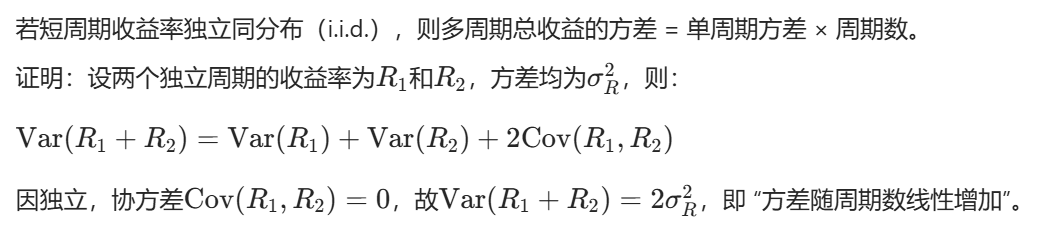

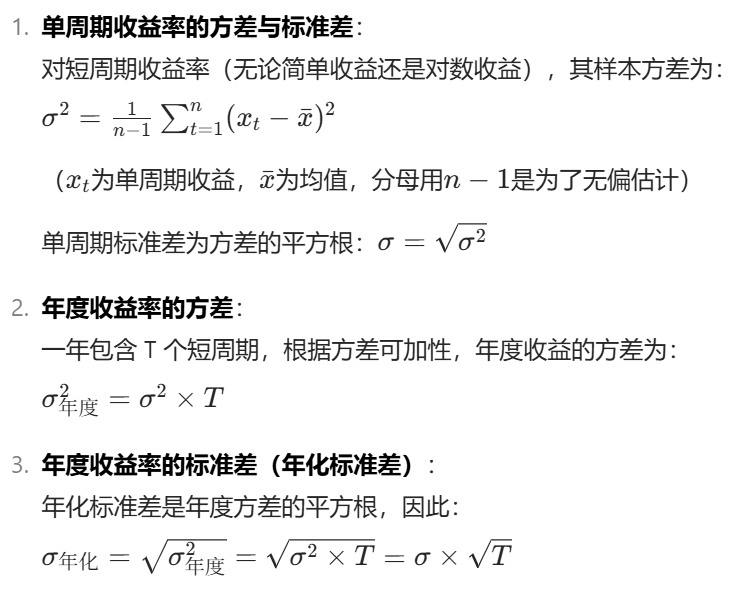

## 课堂练习：对比贵州茅台与寒武纪的收益率分布
- 计算并可视化贵州茅台的对数收益率的分布
- 对比贵州茅台与寒武纪的对数收益率的分布差异
- 对比年化标准差

In [ ]:
# 对比贵州茅台与寒武纪的收益率分布






# 风险调整后的收益率
- 夏普比率

$$\text{Sharpe Ratio} = \frac{E(r_p) - r_f}{\sigma_p}$$

其中：
- $E(r_p)$：投资组合对数收益率的**年化均值**
  - 若为日收益率数据，需乘以 $252$
  - 若为周收益率数据，需乘以 $52$
- $r_f$：无风险利率（通常采用国债收益率，需注意与收益周期匹配，例如使用年化无风险利率）
- $\sigma_p$：投资组合对数收益率的**年化标准差**
  - 若为日收益率数据，标准差乘以 $\sqrt{252}$
  - 若为周收益率数据，标准差乘以 $\sqrt{52}$

## 课堂练习：请大家根据上述公式，计算寒武纪和贵州茅台风险调整后的收益率：夏普比率

| 夏普比率范围 | 评价                               |
| :----------- | :--------------------------------- |
| < 0          | 收益低于无风险利率，表现差           |
| 0 ~ 1        | 收益补偿了风险，但表现一般           |
| ≥ 1          | **良好**，风险调整后收益不错         |
| ≥ 2          | **优秀**                           |
| ≥ 3          | **卓越**                           |

In [ ]:
# 计算寒武纪和贵州茅台风险调整后的收益率：夏普比率





# 文献分享 - Are Monthly Seasonals Real? A Three Century Perspective

- 研究话题
- 研究设计
- 数据来源
- 分析结果

# 课后作业
中国股市存在月度效应吗？基于上涨指数月度数据的实证分析